In [7]:
import numpy as np 
import matplotlib.pyplot as plt 
from sklearn import datasets
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import make_pipeline

In [9]:
# Load the diabetes dataset
diabetes = datasets.load_diabetes()

# See what's inside
print(diabetes.keys())
print(diabetes.DESCR)

dict_keys(['data', 'target', 'frame', 'DESCR', 'feature_names', 'data_filename', 'target_filename', 'data_module'])
.. _diabetes_dataset:

Diabetes dataset
----------------

Ten baseline variables, age, sex, body mass index, average blood
pressure, and six blood serum measurements were obtained for each of n =
442 diabetes patients, as well as the response of interest, a
quantitative measure of disease progression one year after baseline.

**Data Set Characteristics:**

:Number of Instances: 442

:Number of Attributes: First 10 columns are numeric predictive values

:Target: Column 11 is a quantitative measure of disease progression one year after baseline

:Attribute Information:
    - age     age in years
    - sex
    - bmi     body mass index
    - bp      average blood pressure
    - s1      tc, total serum cholesterol
    - s2      ldl, low-density lipoproteins
    - s3      hdl, high-density lipoproteins
    - s4      tch, total cholesterol / HDL
    - s5      ltg, possibly log 

In [10]:
# We will use BMI to predict diabetes progression
# BMI is stored at index 2 in the dataset
X = diabetes.data[:, 2].reshape(-1, 1)
y = diabetes.target

# Check the shape of out data
print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (442, 1)
y shape: (442,)


In [11]:
# Split data into 80% training and 20% testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

# Check the sizes
print("Training size", X_train.shape)
print("Testing size", X_test.shape)

Training size (353, 1)
Testing size (89, 1)


In [12]:
# Create and train the Linear Regression model
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)

# Print the model coefficients
print("Slope (coefficient):", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)

Slope (coefficient): [981.65543614]
Intercept: 152.28824927379569


In [14]:
# Make predictions on the test data
pred = lin_reg.predict(X_test)

# Calculate RMSE
rmse = np.sqrt(mean_squared_error(y_test, pred))
print(f"RMSE: {rmse:.2f}")

# Calculate R² (coefficient of determination)
score = lin_reg.score(X_test, y_test)
print(f"R² Score: {score:.2f}")

RMSE: 64.43
R² Score: 0.19


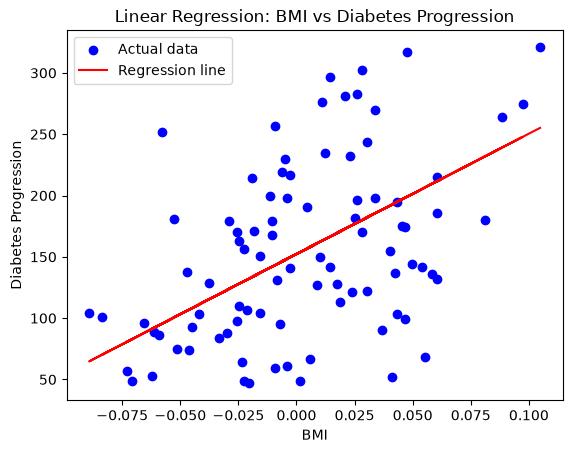

In [15]:
# Plot the actual data points and our regression line
plt.scatter(X_test, y_test, color='blue', label='Actual data')
plt.plot(X_test, pred, color='red', label='Regression line')

# Labels and title
plt.xlabel('BMI')
plt.ylabel('Diabetes Progression')
plt.title('Linear Regression: BMI vs Diabetes Progression')
plt.legend()
plt.show()

In [16]:
# Build a Polynomial Regression pipeline (degree 2)
poly_pipeline = make_pipeline(PolynomialFeatures(2), LinearRegression())
poly_pipeline.fit(X_train, y_train)

# Predict and measure
ploy_pred = poly_pipeline.predict(X_test)
poly_rmse = np.sqrt(mean_squared_error(y_test, ploy_pred))
poly_score = poly_pipeline.score(X_test, y_test)

print(f"Polynomial RMSE: {poly_rmse:.2f}")
print(f"Polynomial R² Score: {poly_score:.2f}")

Polynomial RMSE: 64.41
Polynomial R² Score: 0.19


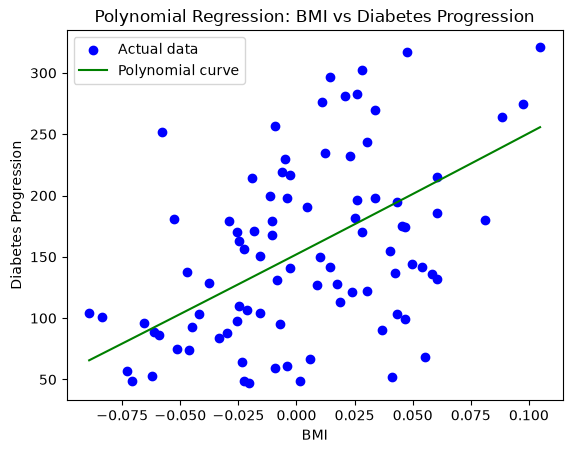

In [18]:
# Create a smooth range of values for plotting the curve
X_range = np.linspace(X_test.min(), X_test.max(), 100).reshape(-1, 1)
y_range = poly_pipeline.predict(X_range)

# Plot actual data points and polynomial curve
plt.scatter(X_test, y_test, color='blue', label='Actual data')
plt.plot(X_range, y_range, color='green', label='Polynomial curve')
plt.xlabel('BMI')
plt.ylabel('Diabetes Progression')
plt.title('Polynomial Regression: BMI vs Diabetes Progression')
plt.legend()
plt.show()

In [24]:
# Summary comparison of both models
print("=" * 50)
print("MODEL COMPARISON SUMMARY")
print("=" * 50)
print(f"Linear Regression      RMSE: {rmse:.2f}     R²: {score:.2f}")
print(f"Polynomial Regression  RMSE: {poly_rmse:.2f}     R²: {poly_score:.2f}")
print("=" * 50)
print("\nConclusion:")
print("BMI alone is a weak predictor of diabetes progression.")
print("Polynomial regression showed minimal improvement over linear.")
print("A stronger model would require more features like age, blood pressure etc.")

MODEL COMPARISON SUMMARY
Linear Regression      RMSE: 64.43     R²: 0.19
Polynomial Regression  RMSE: 64.41     R²: 0.19

Conclusion:
BMI alone is a weak predictor of diabetes progression.
Polynomial regression showed minimal improvement over linear.
A stronger model would require more features like age, blood pressure etc.


## Assignment — Build a Regression Model
### Dataset: Scikit-learn Diabetes Dataset

### Why I chose this dataset:
The diabetes dataset is a clean, built-in dataset with a clear numeric target 
(disease progression) making it ideal for practicing regression techniques.

### Why I chose BMI as the feature:
BMI (Body Mass Index) is a well-known health indicator. I expected it to have 
a meaningful relationship with diabetes progression, making it a logical 
first feature to test.

### Why I chose Linear Regression first:
The relationship between BMI and progression appeared roughly linear from the 
scatter plot, so simple linear regression was the natural starting point.

### Why I added Polynomial Regression:
To test whether a curved line would better fit the data than a straight line.

### Results:
- Linear Regression: RMSE 64.43, R² 0.19
- Polynomial Regression: RMSE 64.41, R² 0.19

### Why the accuracy is low:
BMI alone cannot fully explain diabetes progression. The disease is influenced 
by many factors — age, blood pressure, cholesterol, and other measurements. 
A stronger model would use all available features together, which would 
significantly improve accuracy.